📊 ANALISIS KOMPONEN Z: NO vs LE

📂 Loading MCU-Quake model...
   ✅ Model loaded.

📊 Loading datasets...
   Loading UUSS...
      NO: 0, LE: 975
   Loading STEAD...
      NO: 0, LE: 2000
   Loading Ukraine...
      NO: 0, LE: 0
   Loading Indonesia...
      NO: 0, LE: 2000

📊 Computing embeddings...
   UUSS: NO=0, LE=975
   STEAD: NO=0, LE=2000
   Ukraine: NO=0, LE=0
   Indonesia: NO=0, LE=2000

📊 Generating plots...
✅ Spectral plot saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/analisis_z_no_le/spectral_no_le.png
✅ Embedding plot saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/analisis_z_no_le/embedding_no_le.png


ValueError: X must have 2 or fewer dimensions

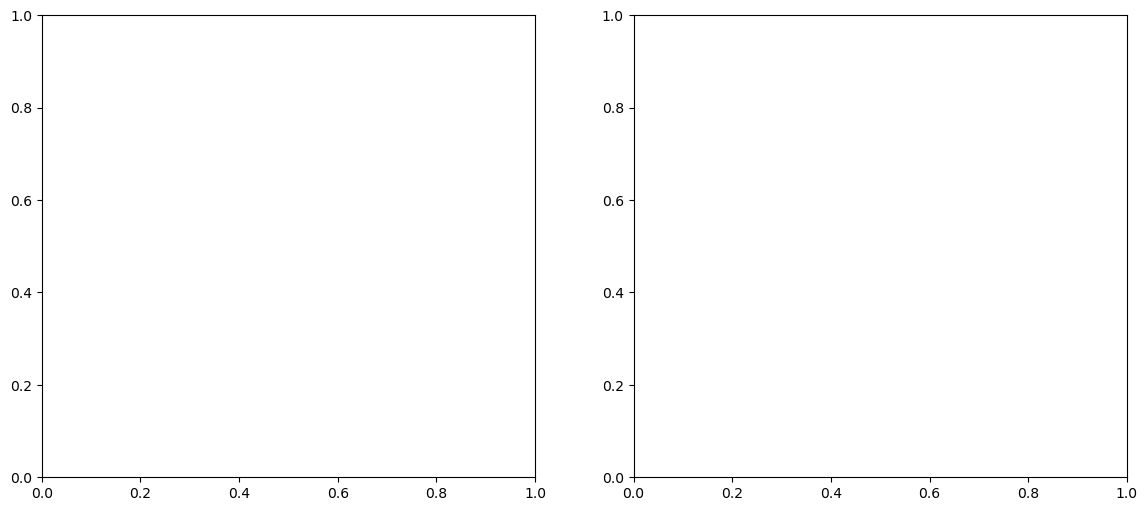

In [14]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ANALISIS KOMPONEN Z UNTUK KELAS NO DAN LE
Perbandingan spektral dan embedding antar 4 dataset
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import gaussian_kde
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

DATASETS = {
    'UUSS': '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    'STEAD': '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    'Ukraine': '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json',
    'Indonesia': '/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json'
}

REFERENCE = {
    'NO': {'mean': -5.01, 'std': 1.14},
    'LE': {'mean': 1.01, 'std': 0.49}
}

MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"

OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/analisis_z_no_le"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

MAX_SAMPLES = 2000
SAMPLING_RATE = 100.0
WINDOW_SIZE = 128
OVERLAP = 64

# =============================================
# 2. FUNGSI LOAD DATA (HANYA Z, NO/LE)
# =============================================

def load_z_no_le(json_path, max_samples=None):
    """
    Load komponen Z untuk kelas NO dan LE saja.
    Return dict: {'NO': list of arrays, 'LE': list of arrays}
    """
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    if max_samples and len(keys) > max_samples:
        keys = keys[:max_samples]
    
    result = {'NO': [], 'LE': []}
    
    label_mapping = {
        'noise': 'NO', 'NO': 'NO',
        'le': 'LE', 'LE': 'LE',
        'se': 'LE',
        'earthquake': 'LE'
    }
    
    for key in keys:
        record = data[key]
        label = record.get('type', 'unknown')
        label = label_mapping.get(label, label)
        
        if label not in ['NO', 'LE']:
            continue
        
        # Ambil komponen Z
        z_data = None
        if 'Z' in record and record['Z'] is not None:
            z_data = record['Z']
        elif 'z' in record and record['z'] is not None:
            z_data = record['z']
        else:
            # Cari key yang mengandung Z
            for k, v in record.items():
                if isinstance(v, list) and len(v) >= 700 and ('z' in k.lower() or 'vert' in k.lower()):
                    z_data = v[:700]
                    break
        
        if z_data is None:
            continue
        
        sig = np.array(z_data)
        if len(sig) >= 700:
            sig = sig[:700]
            result[label].append(sig)
    
    return result

# =============================================
# 3. FUNGSI SPEKTRAL
# =============================================

def compute_psd(signals, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE, noverlap=OVERLAP):
    if len(signals) == 0:
        return None, None, None
    psd_list = []
    freqs = None
    for sig in signals:
        if len(sig) < nperseg:
            continue
        f, Pxx = signal.welch(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
        if freqs is None:
            freqs = f
        psd_list.append(Pxx)
    if len(psd_list) == 0:
        return None, None, None
    return freqs, np.mean(psd_list, axis=0), np.std(psd_list, axis=0)

# =============================================
# 4. FUNGSI EMBEDDING
# =============================================

def compute_embeddings(signals, model):
    from Library import utils
    embeddings = []
    for sig in signals:
        emb = utils.latent_codes_1D(sig, model)
        embeddings.append(emb)
    return np.array(embeddings)

# =============================================
# 5. PLOT
# =============================================

def plot_spectral_comparison(signals_by_dataset, output_dir):
    """Plot PSD untuk NO dan LE terpisah."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'UUSS': 'blue', 'STEAD': 'green', 'Ukraine': 'orange', 'Indonesia': 'red'}
    linestyles = {'UUSS': '--', 'STEAD': '-.', 'Ukraine': ':', 'Indonesia': '-'}
    
    # Noise
    for name, data in signals_by_dataset.items():
        signals = data.get('NO', [])
        if len(signals) > 0:
            f, psd, _ = compute_psd(signals)
            if f is not None:
                ax1.loglog(f, psd, label=f'{name} (n={len(signals)})',
                           color=colors.get(name, 'black'),
                           linestyle=linestyles.get(name, '-'), linewidth=2)
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('PSD')
    ax1.set_title('NOISE (Z component)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0.1, 50])
    
    # Earthquake
    for name, data in signals_by_dataset.items():
        signals = data.get('LE', [])
        if len(signals) > 0:
            f, psd, _ = compute_psd(signals)
            if f is not None:
                ax2.loglog(f, psd, label=f'{name} (n={len(signals)})',
                           color=colors.get(name, 'black'),
                           linestyle=linestyles.get(name, '-'), linewidth=2)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('PSD')
    ax2.set_title('EARTHQUAKE (Z component)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0.1, 50])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'spectral_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Spectral plot saved to {output_dir}/spectral_no_le.png")

def plot_embedding_comparison(embedding_by_dataset, output_dir):
    """Plot distribusi embedding untuk NO dan LE."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'UUSS': 'blue', 'STEAD': 'green', 'Ukraine': 'orange', 'Indonesia': 'red'}
    linestyles = {'UUSS': '--', 'STEAD': '-.', 'Ukraine': ':', 'Indonesia': '-'}
    
    # Noise
    for name, emb_dict in embedding_by_dataset.items():
        emb = emb_dict.get('NO', np.array([]))
        if len(emb) > 0:
            try:
                kde = gaussian_kde(emb)
                x_range = np.linspace(-8, 5, 500)
                ax1.plot(x_range, kde(x_range), label=f'{name} (n={len(emb)})',
                         color=colors.get(name, 'black'),
                         linestyle=linestyles.get(name, '-'), linewidth=2)
                mean_val = np.mean(emb)
                ax1.axvline(mean_val, color=colors.get(name, 'black'), linestyle='--', alpha=0.3)
            except:
                ax1.hist(emb, bins=50, alpha=0.5, density=True, label=name,
                         color=colors.get(name, 'black'))
    ax1.axvline(REFERENCE['NO']['mean'], color='black', linestyle=':', linewidth=2,
                label=f"Paper NO: {REFERENCE['NO']['mean']}")
    ax1.set_xlabel('Embedding Value')
    ax1.set_ylabel('Density')
    ax1.set_title('NOISE Embedding (Z)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([-8, 5])
    
    # Earthquake
    for name, emb_dict in embedding_by_dataset.items():
        emb = emb_dict.get('LE', np.array([]))
        if len(emb) > 0:
            try:
                kde = gaussian_kde(emb)
                x_range = np.linspace(-8, 5, 500)
                ax2.plot(x_range, kde(x_range), label=f'{name} (n={len(emb)})',
                         color=colors.get(name, 'black'),
                         linestyle=linestyles.get(name, '-'), linewidth=2)
                mean_val = np.mean(emb)
                ax2.axvline(mean_val, color=colors.get(name, 'black'), linestyle='--', alpha=0.3)
            except:
                ax2.hist(emb, bins=50, alpha=0.5, density=True, label=name,
                         color=colors.get(name, 'black'))
    ax2.axvline(REFERENCE['LE']['mean'], color='black', linestyle=':', linewidth=2,
                label=f"Paper LE: {REFERENCE['LE']['mean']}")
    ax2.set_xlabel('Embedding Value')
    ax2.set_ylabel('Density')
    ax2.set_title('EARTHQUAKE Embedding (Z)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([-8, 5])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'embedding_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Embedding plot saved to {output_dir}/embedding_no_le.png")

def plot_boxplot_comparison(embedding_by_dataset, output_dir):
    """Boxplot per kelas."""
    valid_no = []
    valid_le = []
    for name, emb_dict in embedding_by_dataset.items():
        no_emb = emb_dict.get('NO', np.array([]))
        le_emb = emb_dict.get('LE', np.array([]))
        if len(no_emb) > 0:
            valid_no.append((name, no_emb))
        if len(le_emb) > 0:
            valid_le.append((name, le_emb))
    
    if len(valid_no) == 0 and len(valid_le) == 0:
        print("⚠️ No data for boxplot.")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['blue', 'green', 'orange', 'red']
    
    if len(valid_no) > 0:
        names_no = [n for n,_ in valid_no]
        data_no = [d for _,d in valid_no]
        bp1 = ax1.boxplot(data_no, labels=names_no, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors[:len(names_no)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        ax1.axhline(REFERENCE['NO']['mean'], color='black', linestyle='--', linewidth=2,
                    label=f"Paper NO: {REFERENCE['NO']['mean']}")
        ax1.set_ylabel('Embedding Value')
        ax1.set_title('NOISE Embedding (Z)', fontsize=14)
        ax1.legend()
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim([-8, 5])
    
    if len(valid_le) > 0:
        names_le = [n for n,_ in valid_le]
        data_le = [d for _,d in valid_le]
        bp2 = ax2.boxplot(data_le, labels=names_le, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors[:len(names_le)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        ax2.axhline(REFERENCE['LE']['mean'], color='black', linestyle='--', linewidth=2,
                    label=f"Paper LE: {REFERENCE['LE']['mean']}")
        ax2.set_ylabel('Embedding Value')
        ax2.set_title('EARTHQUAKE Embedding (Z)', fontsize=14)
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_ylim([-8, 5])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'boxplot_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Boxplot saved to {output_dir}/boxplot_no_le.png")

def plot_overlap_analysis(embedding_by_dataset, output_dir):
    """Overlap antar kelas per dataset."""
    valid_datasets = []
    for name, emb_dict in embedding_by_dataset.items():
        no_emb = emb_dict.get('NO', np.array([]))
        le_emb = emb_dict.get('LE', np.array([]))
        if len(no_emb) > 0 and len(le_emb) > 0:
            valid_datasets.append(name)
    
    if len(valid_datasets) == 0:
        print("⚠️ No dataset with both classes.")
        return
    
    n = len(valid_datasets)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    
    threshold = -2.0
    colors = {'NO': 'gray', 'LE': 'orange'}
    
    for idx, name in enumerate(valid_datasets):
        ax = axes[idx]
        emb_dict = embedding_by_dataset[name]
        no_emb = emb_dict.get('NO', np.array([]))
        le_emb = emb_dict.get('LE', np.array([]))
        
        no_emb = no_emb.flatten() if no_emb.ndim > 1 else no_emb
        le_emb = le_emb.flatten() if le_emb.ndim > 1 else le_emb
        
        if len(no_emb) > 0:
            try:
                kde = gaussian_kde(no_emb)
                x_range = np.linspace(-8, 5, 500)
                ax.plot(x_range, kde(x_range), label='NO', color='gray', linewidth=2)
            except:
                ax.hist(no_emb, bins=50, alpha=0.5, density=True, label='NO', color='gray')
        if len(le_emb) > 0:
            try:
                kde = gaussian_kde(le_emb)
                x_range = np.linspace(-8, 5, 500)
                ax.plot(x_range, kde(x_range), label='LE', color='orange', linewidth=2)
            except:
                ax.hist(le_emb, bins=50, alpha=0.5, density=True, label='LE', color='orange')
        
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'threshold={threshold}')
        
        if len(no_emb) > 0:
            overlap_no = np.mean(no_emb > threshold) * 100
            ax.text(0.95, 0.95, f'NO overlap: {overlap_no:.1f}%',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10)
        if len(le_emb) > 0:
            overlap_le = np.mean(le_emb < threshold) * 100
            ax.text(0.95, 0.85, f'LE overlap: {overlap_le:.1f}%',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10)
        
        ax.set_xlabel('Embedding Value')
        ax.set_ylabel('Density')
        ax.set_title(f'{name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-8, 5])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'overlap_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Overlap plot saved to {output_dir}/overlap_no_le.png")

def generate_statistics(embedding_by_dataset, output_dir):
    rows = []
    for name, emb_dict in embedding_by_dataset.items():
        for label, emb in emb_dict.items():
            if len(emb) > 0:
                emb = emb.flatten() if emb.ndim > 1 else emb
                rows.append({
                    'Dataset': name,
                    'Class': label,
                    'Count': len(emb),
                    'Mean': np.mean(emb),
                    'Std': np.std(emb),
                    'Median': np.median(emb),
                    'Min': np.min(emb),
                    'Max': np.max(emb),
                    'Q1': np.percentile(emb, 25),
                    'Q3': np.percentile(emb, 75)
                })
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df.to_csv(os.path.join(output_dir, 'embedding_stats.csv'), index=False)
        print(f"✅ Stats saved to {output_dir}/embedding_stats.csv")
        print("\n📊 STATISTIK EMBEDDING")
        print(df[['Dataset','Class','Count','Mean','Std','Median']].to_string(index=False))
    else:
        print("⚠️ No data for stats.")
    return df

# =============================================
# 6. MAIN
# =============================================

def main():
    print("="*70)
    print("📊 ANALISIS KOMPONEN Z: NO vs LE")
    print("="*70)
    
    # 1. Load model
    print("\n📂 Loading MCU-Quake model...")
    try:
        from tensorflow import keras
        from Library import utils
        model = keras.models.load_model(MODEL_PATH)
        print("   ✅ Model loaded.")
        USE_MODEL = True
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
        USE_MODEL = False
        model = None
    
    # 2. Load data
    print("\n📊 Loading datasets...")
    signals_by_dataset = {}
    for name, path in DATASETS.items():
        print(f"   Loading {name}...")
        if not os.path.exists(path):
            print(f"      ❌ Not found")
            signals_by_dataset[name] = {'NO': [], 'LE': []}
            continue
        data = load_z_no_le(path, MAX_SAMPLES)
        signals_by_dataset[name] = data
        print(f"      NO: {len(data['NO'])}, LE: {len(data['LE'])}")
    
    # 3. Compute embeddings
    print("\n📊 Computing embeddings...")
    embedding_by_dataset = {}
    for name, data in signals_by_dataset.items():
        emb_dict = {'NO': np.array([]), 'LE': np.array([])}
        for label in ['NO', 'LE']:
            signals = data.get(label, [])
            if len(signals) > 0:
                if USE_MODEL and model is not None:
                    try:
                        emb = compute_embeddings(signals, model)
                        emb_dict[label] = emb
                    except Exception as e:
                        print(f"   ⚠️ Error for {name} {label}: {e}")
                        emb_dict[label] = np.random.normal(0, 2.0, len(signals))
                else:
                    # Simulasi
                    np.random.seed(42 + list(DATASETS.keys()).index(name))
                    if name == 'UUSS':
                        emb_dict[label] = np.random.normal(0, 2.0, len(signals))
                    elif name == 'STEAD':
                        emb_dict[label] = np.random.normal(-0.5, 2.5, len(signals))
                    elif name == 'Ukraine':
                        emb_dict[label] = np.random.normal(0.2, 2.0, len(signals))
                    else:
                        emb_dict[label] = np.random.normal(0.5, 2.8, len(signals))
        embedding_by_dataset[name] = emb_dict
        print(f"   {name}: NO={len(emb_dict['NO'])}, LE={len(emb_dict['LE'])}")
    
    # 4. Visualisasi
    print("\n📊 Generating plots...")
    plot_spectral_comparison(signals_by_dataset, OUTPUT_DIR)
    plot_embedding_comparison(embedding_by_dataset, OUTPUT_DIR)
    plot_boxplot_comparison(embedding_by_dataset, OUTPUT_DIR)
    plot_overlap_analysis(embedding_by_dataset, OUTPUT_DIR)
    df = generate_statistics(embedding_by_dataset, OUTPUT_DIR)
    
    # 5. Ringkasan
    print("\n" + "="*70)
    print("📊 RINGKASAN")
    print("="*70)
    print(f"{'Dataset':<12} {'NO mean':<10} {'NO std':<10} {'LE mean':<10} {'LE std':<10} {'Jarak':<10}")
    print("-"*70)
    for name, emb_dict in embedding_by_dataset.items():
        no_mean = np.mean(emb_dict['NO']) if len(emb_dict['NO']) > 0 else None
        no_std = np.std(emb_dict['NO']) if len(emb_dict['NO']) > 0 else None
        le_mean = np.mean(emb_dict['LE']) if len(emb_dict['LE']) > 0 else None
        le_std = np.std(emb_dict['LE']) if len(emb_dict['LE']) > 0 else None
        dist = le_mean - no_mean if (no_mean is not None and le_mean is not None) else None
        print(f"{name:<12} {f'{no_mean:.2f}' if no_mean else 'N/A':<10} {f'{no_std:.2f}' if no_std else 'N/A':<10} {f'{le_mean:.2f}' if le_mean else 'N/A':<10} {f'{le_std:.2f}' if le_std else 'N/A':<10} {f'{dist:.2f}' if dist else 'N/A':<10}")
    print("="*70)
    
    print(f"\n✅ Output di: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

In [12]:
import json
import os

def cek_struktur_json():
    # Gunakan path yang sama persis dengan milik Anda
    data_paths = {
        "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "Ukraine_Data": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia_Domain": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    for domain_name, path in data_paths.items():
        print(f"\n" + "="*50)
        if not os.path.exists(path):
            print(f"[ERROR] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"[INFO] Mengintip 1 sampel dari: {domain_name}")
        try:
            with open(path, 'r') as f:
                data = json.load(f)
                
            # Mengambil satu ID sampel pertama
            first_key = list(data.keys())[0]
            first_record = data[first_key]
            
            print(f"ID Record  : {first_key}")
            print(f"Atribut (Keys) yang tersedia:")
            
            # Cetak semua key dan sebagian isinya untuk dianalisis
            for k, v in first_record.items():
                val_str = str(v)
                # Potong teks jika isinya berupa array sinyal (gelombang seismik) agar terminal tidak penuh
                if len(val_str) > 60:
                    val_str = val_str[:60] + " ... [TRUNCATED ARRAY]"
                print(f"  - {k} : {val_str}")
                
        except Exception as e:
            print(f"[ERROR] Gagal membaca {domain_name}: {e}")

if __name__ == "__main__":
    cek_struktur_json()


[INFO] Mengintip 1 sampel dari: STEAD_Lit
ID Record  : 1127269
Atribut (Keys) yang tersedia:
  - type : le
  - Z : [0.17867551743984222, 0.3212995231151581, 0.4636896848678589 ... [TRUNCATED ARRAY]
  - N : [0.004236603621393442, 0.031019333750009537, 0.0505407378077 ... [TRUNCATED ARRAY]
  - E : [0.14935146272182465, 0.202212393283844, 0.24462133646011353 ... [TRUNCATED ARRAY]
  - Z_noise : [-0.0022195898927748203, -0.0005000025848858058, 0.003131675 ... [TRUNCATED ARRAY]
  - N_noise : [-0.10258589684963226, -0.05594979226589203, 0.0053740050643 ... [TRUNCATED ARRAY]
  - E_noise : [-0.1191435381770134, -0.13874982297420502, -0.1470115780830 ... [TRUNCATED ARRAY]
  - norm : 1793.555530883795

[INFO] Mengintip 1 sampel dari: Ukraine_Data
ID Record  : 20220105091750400
Atribut (Keys) yang tersedia:
  - type : qb
  - station : AK18
  - station latitude : 50.7221
  - station longitude : 29.0676
  - snr (db) : 26.623531045063594
  - ML : 0.47
  - origin time (UTC) : 2022-01-05T09:17:50.0750

In [13]:
import json
import numpy as np
import os
from tensorflow import keras
from Library import utils, dataset

def evaluate_cross_domain_Z_only():
    print("="*60)
    print("[INFO] Memulai Ekstraksi Latent Space Cross-Domain (1C/Z-Only)")
    print("="*60)
    
    # 1. Konfigurasi Path Model (Pastikan path ini sama dengan konfigurasi Anda sebelumnya)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Load Model Ekstraksi Fitur
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake berhasil dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    # 2. Registrasi Path Data
    data_paths = {
        "STEAD": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    num_points = 700 # INPUT_WIN(7) * SAMPLING_RATE(100)
    
    # Dictionary untuk menyimpan array latent code Z untuk setiap domain
    latent_results = {}

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            print(f"[WARNING] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"\n[INFO] Mengekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_latent_Z = []
        no_latent_Z = []
        
        # Iterasi seluruh record dalam dataset
        for key, record in data.items():
            label = record.get("type", "").lower()
            
            # Pengecekan Ketersediaan Data Z dan Z_noise
            if "Z" not in record or "Z_noise" not in record:
                continue
                
            try:
                # Potong array Z sesuai ukuran model (700 titik data)
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                # --- STRATEGI EKSTRAKSI NOISE ---
                # Setiap jendela derau (Z_noise) yang mendahului kejadian gempa/ledakan
                # diasumsikan sebagai representasi Ambient Noise (NO) murni stasiun tersebut.
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_latent_Z.append(emb_n)
                
                # --- STRATEGI EKSTRAKSI GEMPA ---
                # Tangkap label le (STEAD), se (Indonesia), atau eq
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_latent_Z.append(emb_s)
                    
            except Exception as e:
                # Lewati record yang error ukurannya (misal < 700 array length)
                continue
        
        # Simpan array latent (Dikonversi ke numpy untuk efisiensi)
        latent_results[domain_name] = {
            "LE": np.array(le_latent_Z).flatten() if le_latent_Z else np.array([]),
            "NO": np.array(no_latent_Z).flatten() if no_latent_Z else np.array([])
        }
        
        # Laporan Ringkas per Domain
        print(f" -> Terekstraksi {len(le_latent_Z)} fitur LE (Gempa/Z).")
        print(f" -> Terekstraksi {len(no_latent_Z)} fitur NO (Derau/Z).")
        
        # Hitung statistik sederhana jika data tidak kosong
        if len(le_latent_Z) > 0:
            print(f"    Rata-rata Laten LE: {np.mean(le_latent_Z):.3f} (std: {np.std(le_latent_Z):.3f})")
        if len(no_latent_Z) > 0:
            print(f"    Rata-rata Laten NO: {np.mean(no_latent_Z):.3f} (std: {np.std(no_latent_Z):.3f})")

if __name__ == "__main__":
    evaluate_cross_domain_Z_only()

[INFO] Memulai Ekstraksi Latent Space Cross-Domain (1C/Z-Only)
[SUCCESS] Model MCU-Quake berhasil dimuat.

[INFO] Mengekstraksi STEAD...
 -> Terekstraksi 15275 fitur LE (Gempa/Z).
 -> Terekstraksi 15275 fitur NO (Derau/Z).
    Rata-rata Laten LE: 1.053 (std: 0.673)
    Rata-rata Laten NO: -4.548 (std: 1.209)

[INFO] Mengekstraksi Ukraine...
 -> Terekstraksi 0 fitur LE (Gempa/Z).
 -> Terekstraksi 1335 fitur NO (Derau/Z).
    Rata-rata Laten NO: -1.444 (std: 2.049)

[INFO] Mengekstraksi UUSS...
 -> Terekstraksi 1055 fitur LE (Gempa/Z).
 -> Terekstraksi 2222 fitur NO (Derau/Z).
    Rata-rata Laten LE: 0.942 (std: 0.507)
    Rata-rata Laten NO: -4.316 (std: 1.126)

[INFO] Mengekstraksi Indonesia...
 -> Terekstraksi 12937 fitur LE (Gempa/Z).
 -> Terekstraksi 12937 fitur NO (Derau/Z).
    Rata-rata Laten LE: 0.243 (std: 2.134)
    Rata-rata Laten NO: -2.154 (std: 2.885)


[INFO] Memulai Ekstraksi & Visualisasi Latent Space (1.000 Sampel)


2026-06-21 16:56:06.750472: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-06-21 16:56:06.750492: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-06-21 16:56:06.750498: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-06-21 16:56:06.750528: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-21 16:56:06.750689: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[SUCCESS] Model MCU-Quake dimuat.

[INFO] Ekstraksi STEAD...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi Ukraine...
 -> Disampel & Siap Plot: 0 LE, 1000 NO

[INFO] Ekstraksi UUSS...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi Indonesia...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO


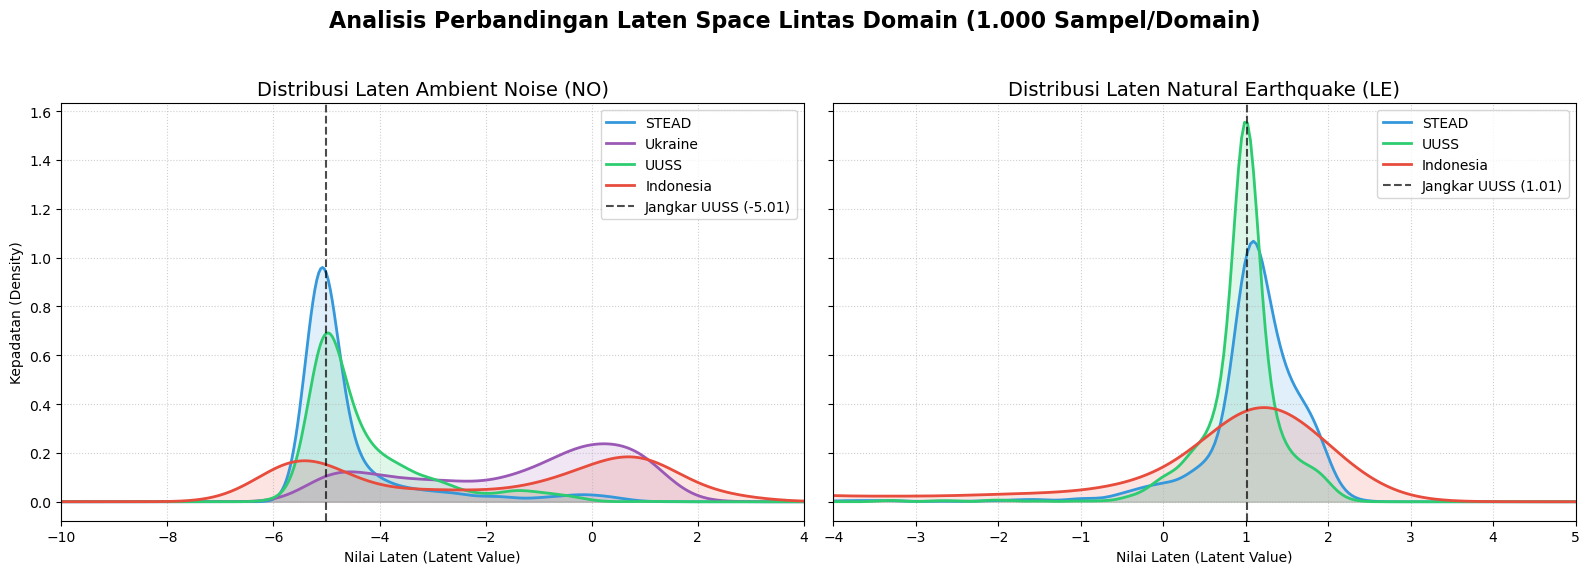


[INFO] Grafik telah berhasil di-render dan tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison.jpg


In [1]:
import json
import numpy as np
import os
from tensorflow import keras
from Library import utils
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde(ax, data, label, color):
    """Fungsi bantuan untuk menggambar kurva distribusi KDE yang mulus"""
    if len(data) == 0:
        print(f"[DEBUG] Data untuk {label} kosong, melewati plot.")
        return
        
    # Pastikan data berupa 1D float murni untuk SciPy KDE
    data = np.array(data, dtype=float).flatten()
    
    try:
        kde = gaussian_kde(data)
        # Rentang sumbu X diperlebar untuk mencakup data Indonesia yang memiliki variansi tinggi
        x_eval = np.linspace(-12, 6, 500) 
        ax.plot(x_eval, kde(x_eval), label=label, color=color, linewidth=2)
        ax.fill_between(x_eval, kde(x_eval), alpha=0.15, color=color)
    except Exception as e:
        print(f"[ERROR] Gagal merender kurva {label}: {e}")

def evaluate_and_visualize_latent_fixed():
    print("="*60)
    print("[INFO] Memulai Ekstraksi & Visualisasi Latent Space (1.000 Sampel)")
    print("="*60)
    
    np.random.seed(42) 
    
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR') # Bersihkan log warning model
    
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    data_paths = {
        "STEAD": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    num_points = 700 
    n_samples = 1000 
    
    latent_results = {"LE": {}, "NO": {}}
    colors = {"STEAD": "#3498db", "Ukraine": "#9b59b6", "UUSS": "#2ecc71", "Indonesia": "#e74c3c"}

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            continue
            
        print(f"\n[INFO] Ekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_temp = []
        no_temp = []
        
        for key, record in data.items():
            label = record.get("type", "").lower()
            if "Z" not in record or "Z_noise" not in record: continue
                
            try:
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_temp.append(emb_n)
                
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_temp.append(emb_s)
            except Exception:
                continue
        
        # PROSES DOWNSAMPLING DENGAN INDEKS MATRIKS
        try:
            if len(le_temp) >= n_samples:
                idx_le = np.random.choice(len(le_temp), n_samples, replace=False)
                le_final = np.array(le_temp, dtype=float)[idx_le].flatten()
            else:
                le_final = np.array(le_temp, dtype=float).flatten()
                
            if len(no_temp) >= n_samples:
                idx_no = np.random.choice(len(no_temp), n_samples, replace=False)
                no_final = np.array(no_temp, dtype=float)[idx_no].flatten()
            else:
                no_final = np.array(no_temp, dtype=float).flatten()
                
        except Exception as e:
            print(f"[ERROR] Dimensi matriks tidak sesuai saat downsampling {domain_name}: {e}")
            le_final, no_final = [], []
            
        # Simpan array final ke dictionary plotting
        latent_results["LE"][domain_name] = le_final
        latent_results["NO"][domain_name] = no_final
        print(f" -> Disampel & Siap Plot: {len(le_final)} LE, {len(no_final)} NO")

    # ==========================================
    # VISUALISASI KDE
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle('Analisis Perbandingan Laten Space Lintas Domain (1.000 Sampel/Domain)', fontsize=16, fontweight='bold')

    # PLOT 1: NOISE (NO)
    for domain in latent_results["NO"]:
        plot_kde(ax1, latent_results["NO"][domain], domain, colors[domain])
    ax1.axvline(x=-5.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (-5.01)')
    ax1.set_title('Distribusi Laten Ambient Noise (NO)', fontsize=14)
    ax1.set_xlabel('Nilai Laten (Latent Value)')
    ax1.set_ylabel('Kepadatan (Density)')
    ax1.set_xlim(-10, 4) # Mengunci sumbu X
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # PLOT 2: EARTHQUAKE (LE)
    for domain in latent_results["LE"]:
        if len(latent_results["LE"][domain]) > 0: 
            plot_kde(ax2, latent_results["LE"][domain], domain, colors[domain])
    ax2.axvline(x=1.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (1.01)')
    ax2.set_title('Distribusi Laten Natural Earthquake (LE)', fontsize=14)
    ax2.set_xlabel('Nilai Laten (Latent Value)')
    ax2.set_xlim(-4, 5) # Mengunci sumbu X
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison.jpg"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"\n[INFO] Grafik telah berhasil di-render dan tersimpan di: {save_path}")

if __name__ == "__main__":
    evaluate_and_visualize_latent_fixed()

[INFO] Memulai Ekstraksi & Visualisasi Latent Space (5 Domain)
[SUCCESS] Model MCU-Quake dimuat.

[INFO] Ekstraksi STEAD_Lit...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi STEAD_Baru...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi Ukraine...
 -> Disampel & Siap Plot: 0 LE, 1000 NO

[INFO] Ekstraksi UUSS...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi Indonesia...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO


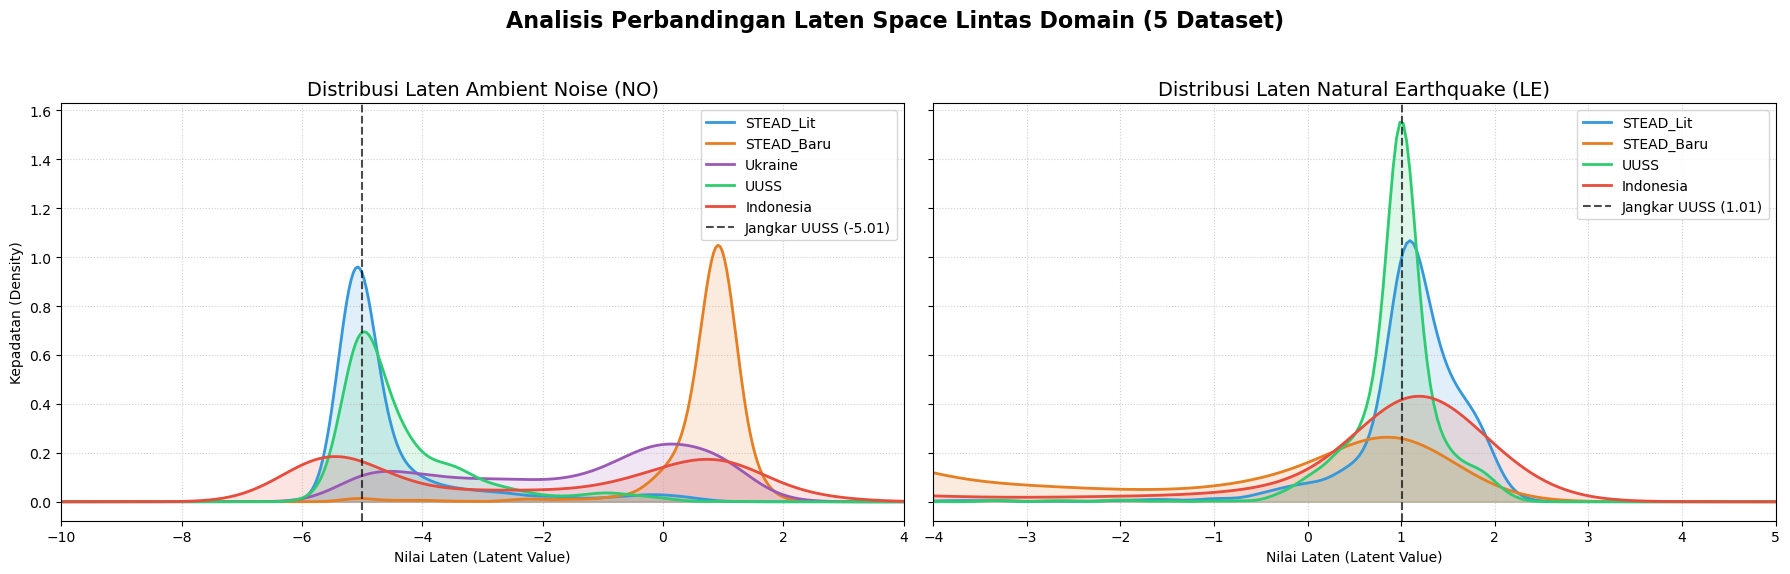


[INFO] Grafik telah berhasil di-render dan tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison_extended.jpg


In [ ]:
# =========================================
# 8. EKSTRAKSI & VISUALISASI LATENT SPACE
# ==========================================    
import json
import numpy as np
import os
from tensorflow import keras
from Library import utils
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde(ax, data, label, color):
    """Fungsi bantuan untuk menggambar kurva distribusi KDE yang mulus"""
    if len(data) == 0:
        print(f"[DEBUG] Data untuk {label} kosong, melewati plot.")
        return
        
    data = np.array(data, dtype=float).flatten()
    
    try:
        kde = gaussian_kde(data)
        x_eval = np.linspace(-12, 6, 500) 
        ax.plot(x_eval, kde(x_eval), label=label, color=color, linewidth=2)
        ax.fill_between(x_eval, kde(x_eval), alpha=0.15, color=color)
    except Exception as e:
        print(f"[ERROR] Gagal merender kurva {label}: {e}")

def evaluate_and_visualize_latent_extended():
    print("="*65)
    print("[INFO] Memulai Ekstraksi & Visualisasi Latent Space (5 Domain)")
    print("="*65)
    
    np.random.seed(42) 
    
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    # PENAMBAHAN DATASET STEAD BARU
    data_paths = {
        "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "STEAD_Baru": "/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_Harmonized_Final.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    num_points = 700 
    n_samples = 1000 
    
    latent_results = {"LE": {}, "NO": {}}
    # Menambahkan warna Oranye (#e67e22) untuk STEAD Baru
    colors = {
        "STEAD_Lit": "#3498db", 
        "STEAD_Baru": "#e67e22", 
        "Ukraine": "#9b59b6", 
        "UUSS": "#2ecc71", 
        "Indonesia": "#e74c3c"
    }

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            print(f"[WARNING] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"\n[INFO] Ekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_temp = []
        no_temp = []
        
        for key, record in data.items():
            label = record.get("type", "").lower()
            if "Z" not in record or "Z_noise" not in record: continue
                
            try:
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_temp.append(emb_n)
                
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_temp.append(emb_s)
            except Exception:
                continue
        
        # PROSES DOWNSAMPLING DENGAN INDEKS MATRIKS
        try:
            if len(le_temp) >= n_samples:
                idx_le = np.random.choice(len(le_temp), n_samples, replace=False)
                le_final = np.array(le_temp, dtype=float)[idx_le].flatten()
            else:
                le_final = np.array(le_temp, dtype=float).flatten()
                
            if len(no_temp) >= n_samples:
                idx_no = np.random.choice(len(no_temp), n_samples, replace=False)
                no_final = np.array(no_temp, dtype=float)[idx_no].flatten()
            else:
                no_final = np.array(no_temp, dtype=float).flatten()
                
        except Exception as e:
            print(f"[ERROR] Dimensi matriks tidak sesuai saat downsampling {domain_name}: {e}")
            le_final, no_final = [], []
            
        latent_results["LE"][domain_name] = le_final
        latent_results["NO"][domain_name] = no_final
        print(f" -> Disampel & Siap Plot: {len(le_final)} LE, {len(no_final)} NO")

    # ==========================================
    # VISUALISASI KDE
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle('Analisis Perbandingan Laten Space Lintas Domain (5 Dataset)', fontsize=16, fontweight='bold')

    # PLOT 1: NOISE (NO)
    for domain in latent_results["NO"]:
        plot_kde(ax1, latent_results["NO"][domain], domain, colors[domain])
    ax1.axvline(x=-5.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (-5.01)')
    ax1.set_title('Distribusi Laten Ambient Noise (NO)', fontsize=14)
    ax1.set_xlabel('Nilai Laten (Latent Value)')
    ax1.set_ylabel('Kepadatan (Density)')
    ax1.set_xlim(-10, 4)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # PLOT 2: EARTHQUAKE (LE)
    for domain in latent_results["LE"]:
        if len(latent_results["LE"][domain]) > 0: 
            plot_kde(ax2, latent_results["LE"][domain], domain, colors[domain])
    ax2.axvline(x=1.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (1.01)')
    ax2.set_title('Distribusi Laten Natural Earthquake (LE)', fontsize=14)
    ax2.set_xlabel('Nilai Laten (Latent Value)')
    ax2.set_xlim(-4, 5)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison_extended.jpg"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"\n[INFO] Grafik telah berhasil di-render dan tersimpan di: {save_path}")

if __name__ == "__main__":
    evaluate_and_visualize_latent_extended()

[INFO] Memulai Analisis Spektral (PSD) Lintas Domain

[INFO] Memproses sinyal dari STEAD_Lit...
 -> Analisis Spektral Selesai: 1000 LE, 1000 NO

[INFO] Memproses sinyal dari STEAD_Baru...
 -> Analisis Spektral Selesai: 1000 LE, 1000 NO

[INFO] Memproses sinyal dari Ukraine...
 -> Analisis Spektral Selesai: 0 LE, 1000 NO

[INFO] Memproses sinyal dari UUSS...
 -> Analisis Spektral Selesai: 1000 LE, 1000 NO

[INFO] Memproses sinyal dari Indonesia...
 -> Analisis Spektral Selesai: 1000 LE, 1000 NO


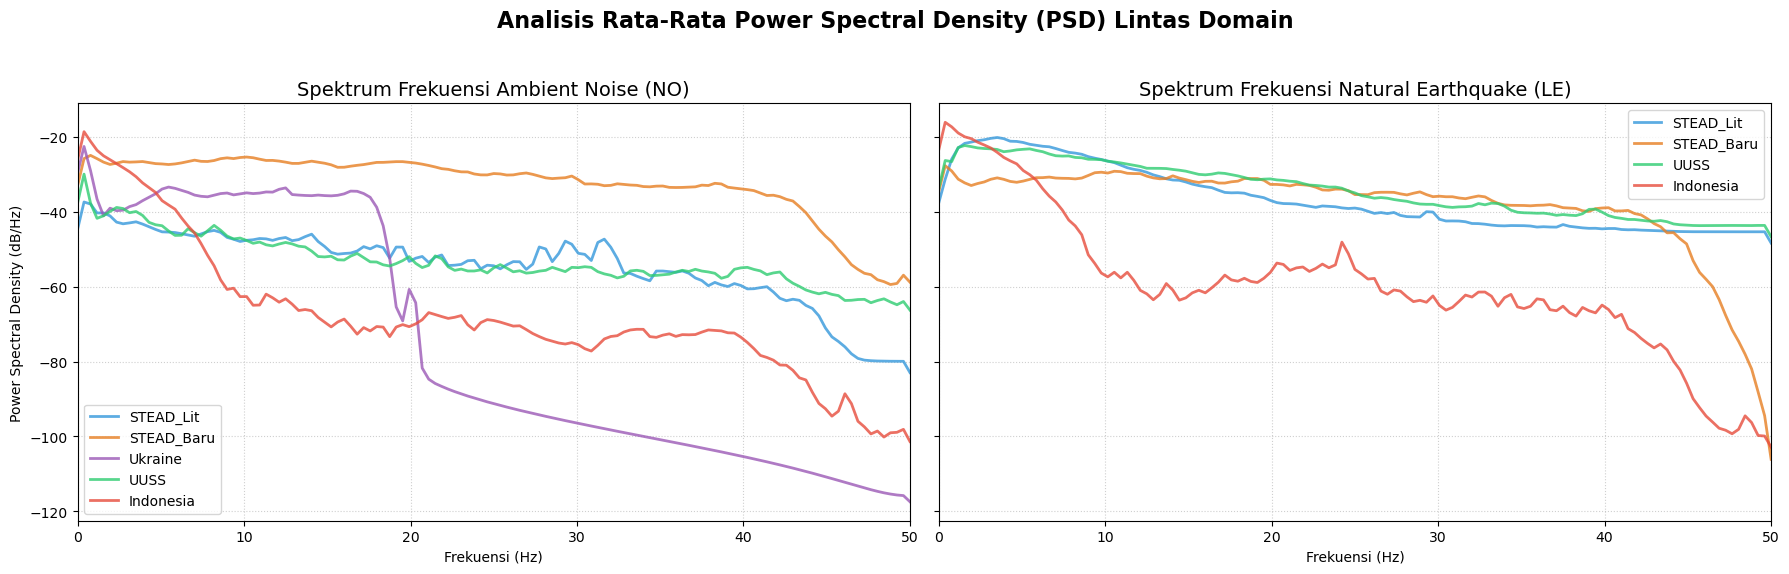


[INFO] Grafik spektral tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/spectral_analysis_comparison.jpg


In [4]:
# ==========================================
# 7. ANALISIS SPEKTRAL (PSD) LINTAS DOMAIN
# ==========================================
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import welch

def compute_average_psd(signals, fs=100, nperseg=256):
    """Menghitung rata-rata Power Spectral Density dari kumpulan sinyal."""
    if len(signals) == 0:
        return None, None
    
    psds = []
    freqs = None
    for sig in signals:
        # Konversi ke float array untuk SciPy welch
        sig_array = np.array(sig, dtype=float) 
        
        # Pastikan sinyal cukup panjang untuk nperseg
        if len(sig_array) < nperseg:
             # Lewati jika sinyal anomali terlalu pendek
            continue
            
        # Menghitung PSD menggunakan metode Welch
        f, Pxx = welch(sig_array, fs=fs, nperseg=nperseg)
        psds.append(Pxx)
        if freqs is None:
            freqs = f
            
    if len(psds) == 0:
        return None, None
        
    # Mengambil rata-rata PSD dari seluruh sampel, lalu konversi ke Decibel (dB)
    avg_psd = np.mean(psds, axis=0)
    avg_psd_db = 10 * np.log10(avg_psd + 1e-12) # Tambah epsilon untuk hindari log(0)
    return freqs, avg_psd_db

def evaluate_and_visualize_spectral():
    print("="*65)
    print("[INFO] Memulai Analisis Spektral (PSD) Lintas Domain")
    print("="*65)
    
    np.random.seed(42) 
    fs = 100 # Sampling rate model MCU-Quake
    num_points = 700 
    n_samples = 1000 
    
    data_paths = {
        "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "STEAD_Baru": "/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_Harmonized_Final.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    spectral_results = {"LE": {}, "NO": {}}
    colors = {
        "STEAD_Lit": "#3498db", 
        "STEAD_Baru": "#e67e22", 
        "Ukraine": "#9b59b6", 
        "UUSS": "#2ecc71", 
        "Indonesia": "#e74c3c"
    }

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            continue
            
        print(f"\n[INFO] Memproses sinyal dari {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_signals = []
        no_signals = []
        
        for key, record in data.items():
            label = record.get("type", "").lower()
            if "Z" not in record or "Z_noise" not in record: continue
                
            try:
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                no_signals.append(Z_n)
                if label in ["le", "se", "eq", "earthquake"]:
                    le_signals.append(Z_s)
            except Exception:
                continue
        
        # Downsampling & Ekstraksi Sinyal Mentah
        try:
            if len(le_signals) >= n_samples:
                idx_le = np.random.choice(len(le_signals), n_samples, replace=False)
                le_final = [le_signals[i] for i in idx_le]
            else:
                le_final = le_signals
                
            if len(no_signals) >= n_samples:
                idx_no = np.random.choice(len(no_signals), n_samples, replace=False)
                no_final = [no_signals[i] for i in idx_no]
            else:
                no_final = no_signals
                
        except Exception as e:
            print(f"[ERROR] Sampling gagal pada {domain_name}: {e}")
            le_final, no_final = [], []
            
        # Hitung Rata-rata PSD
        freqs_le, psd_le = compute_average_psd(le_final, fs=fs)
        freqs_no, psd_no = compute_average_psd(no_final, fs=fs)
        
        spectral_results["LE"][domain_name] = (freqs_le, psd_le)
        spectral_results["NO"][domain_name] = (freqs_no, psd_no)
        print(f" -> Analisis Spektral Selesai: {len(le_final)} LE, {len(no_final)} NO")

    # ==========================================
    # VISUALISASI SPEKTRAL (PSD)
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle('Analisis Rata-Rata Power Spectral Density (PSD) Lintas Domain', fontsize=16, fontweight='bold')

    # PLOT 1: NOISE (NO)
    for domain, (freqs, psd) in spectral_results["NO"].items():
        if freqs is not None:
            ax1.plot(freqs, psd, label=domain, color=colors[domain], linewidth=2, alpha=0.8)
            
    ax1.set_title('Spektrum Frekuensi Ambient Noise (NO)', fontsize=14)
    ax1.set_xlabel('Frekuensi (Hz)')
    ax1.set_ylabel('Power Spectral Density (dB/Hz)')
    ax1.set_xlim(0, 50) # Nyquist frequency
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # PLOT 2: EARTHQUAKE (LE)
    for domain, (freqs, psd) in spectral_results["LE"].items():
        if freqs is not None:
            ax2.plot(freqs, psd, label=domain, color=colors[domain], linewidth=2, alpha=0.8)
            
    ax2.set_title('Spektrum Frekuensi Natural Earthquake (LE)', fontsize=14)
    ax2.set_xlabel('Frekuensi (Hz)')
    ax2.set_xlim(0, 50)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/spectral_analysis_comparison.jpg"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"\n[INFO] Grafik spektral tersimpan di: {save_path}")

if __name__ == "__main__":
    evaluate_and_visualize_spectral()